# Global Mental Health Crisis Index 2026

## Project Overview

This dataset covers **92 countries** across all six WHO regions with **29 indicators** spanning mental health prevalence, healthcare capacity, policy, socioeconomic context, digital behavior, and COVID-19 impact.

**Analysis Type:** Exploratory Data Analysis (EDA) + Comparative Data Analysis (CDA)

**Goal:** Showcase 5 use cases that reveal the state of global mental health.

**Use Cases Covered:**
1. Visualization & Dashboards — Where is the crisis worst?
2. Social Media & Mental Health — Is screen time making it worse?
3. COVID-19 Aftermath — Which regions suffered the most?
4. Policy Analysis — Do mental health laws and budgets help?
5. Inequality Research — Does wealth determine mental health outcomes?


## 1. Setup

Install required packages and import all libraries.

In [1]:
import subprocess
subprocess.run(["pip", "install", "kagglehub", "-q"], check=True)
subprocess.run(["pip", "install", "scikit-learn", "-q"], check=True)
print("All packages ready!")

All packages ready!


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import kagglehub

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 2. Data Loading & Quick Validation

In [3]:
path = kagglehub.dataset_download("alitaqishah/global-mental-health-crisis-index-2026")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("File:", csv_file)
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns.tolist())

File: Global_Mental_Health_Crisis_Index_2026.csv
Shape: (92, 29)

Columns:
['country', 'iso3', 'region', 'income_group', 'depression_pct', 'anxiety_pct', 'suicide_rate_per100k', 'psychiatrists_per100k', 'mh_budget_pct_health', 'mh_spend_usd_per_capita', 'treatment_gap_pct', 'social_media_hours_daily', 'internet_penetration_pct', 'gdp_per_capita_usd', 'population_millions', 'covid_mh_increase_pct', 'youth_mh_crisis_score', 'mh_policy_exists', 'mh_law_exists', 'mh_crisis_index', 'total_affected_millions', 'psychiatrists_per_million', 'mh_investment_gap', 'social_media_mental_health_risk', 'depression_anxiety_comorbidity_est_pct', 'mh_system_score', 'income_group_code', 'data_year', 'data_source']


In [4]:
print("First 5 rows:")
df.head()

First 5 rows:


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_policy_exists,mh_law_exists,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.30,4.50,6.50,0.02,0.80,0.10,97,1.10,16,700,20.40,86,9.50,No,No,87,1.59,0.20,0.08,Low (<1.5h),1.65,3.40,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.40,4.60,8.20,0.04,0.60,0.10,96,1.20,18,600,32.80,85,9.40,No,No,86,2.62,0.40,0.06,Low (<1.5h),1.70,3.10,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.50,4.80,10.20,0.04,1.00,0.10,95,1.40,22,1200,123.40,82,9.30,No,No,84,10.24,0.40,0.10,Low (<1.5h),1.75,4.70,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.00,5.20,15.40,0.05,0.70,0.10,94,2.10,35,1000,15.90,82,9.30,No,No,83,1.46,0.50,0.07,Moderate (1.5-2.5h),2.00,4.10,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.60,4.90,8.60,0.04,0.80,0.10,94,1.60,28,1200,65.50,80,9.20,No,No,82,5.57,0.40,0.07,Moderate (1.5-2.5h),1.80,4.40,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


In [5]:
print("Missing values:")
print(df.isnull().sum())
print()
df.describe()

Missing values:
country                                   0
iso3                                      0
region                                    0
income_group                              0
depression_pct                            0
anxiety_pct                               0
suicide_rate_per100k                      0
psychiatrists_per100k                     0
mh_budget_pct_health                      0
mh_spend_usd_per_capita                   0
treatment_gap_pct                         0
social_media_hours_daily                  0
internet_penetration_pct                  0
gdp_per_capita_usd                        0
population_millions                       0
covid_mh_increase_pct                     0
youth_mh_crisis_score                     0
mh_policy_exists                          0
mh_law_exists                             0
mh_crisis_index                           0
total_affected_millions                   0
psychiatrists_per_million                 0
mh_investment_ga

,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,treatment_gap_pct,social_media_hours_daily,internet_penetration_pct,gdp_per_capita_usd,population_millions,covid_mh_increase_pct,youth_mh_crisis_score,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year
count,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00
mean,4.40,5.63,11.56,7.18,3.76,38.95,58.93,2.21,73.75,22231.61,76.97,49.63,7.41,58.29,7.34,71.82,0.15,2.20,32.96,2.92,2025.00
std,0.75,1.20,9.83,9.49,2.96,63.42,27.88,0.79,24.26,25685.34,210.88,16.32,1.21,13.64,18.30,94.86,0.05,0.38,27.46,1.01,0.00
min,2.90,3.80,3.20,0.02,0.60,0.10,17.00,0.10,8.00,600.00,0.70,26.00,5.10,36.00,0.05,0.20,0.06,1.45,3.10,1.00,2025.00
25%,3.80,4.80,7.57,0.50,1.20,0.73,26.00,1.60,68.75,3975.00,9.47,34.75,6.30,45.75,0.86,5.00,0.11,1.90,9.03,2.00,2025.00
50%,4.40,5.20,9.80,3.15,2.85,8.00,64.50,2.10,82.50,10150.00,24.75,48.00,7.50,58.00,2.22,31.50,0.14,2.20,23.70,3.00,2025.00
75%,4.90,6.10,12.82,12.45,5.65,49.75,84.50,2.80,92.25,33975.00,59.38,62.00,8.40,69.00,5.98,124.50,0.18,2.45,55.88,4.00,2025.00
max,6.30,9.30,87.50,54.90,11.30,320.00,97.00,4.80,99.00,106900.00,1428.60,86.00,9.50,87.00,121.43,549.00,0.24,3.15,100.00,4.00,2025.00


**Validation findings:**
- Each row is one country — 92 countries total.
- No missing values — the dataset is clean and analysis-ready.
- `mh_crisis_index` is our main outcome variable (0–100, higher = worse crisis).
- Mix of numerical columns and categorical ones (`region`, `income_group`, `mh_policy_exists`).


## 3. Exploratory Data Analysis (EDA)

Before comparing groups, we explore the overall distribution of our main variable `mh_crisis_index` to understand its shape, spread, and where a typical country sits on the scale.

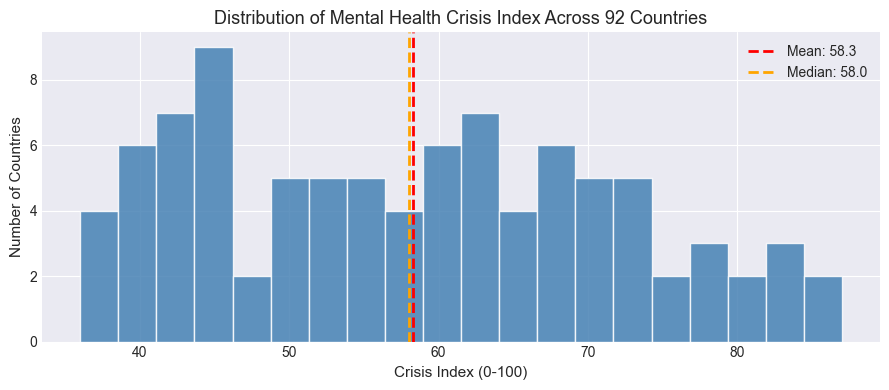

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['mh_crisis_index'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['mh_crisis_index'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {df["mh_crisis_index"].mean():.1f}')
ax.axvline(df['mh_crisis_index'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {df["mh_crisis_index"].median():.1f}')
ax.set_title('Distribution of Mental Health Crisis Index Across 92 Countries', fontsize=13)
ax.set_xlabel('Crisis Index (0-100)', fontsize=11)
ax.set_ylabel('Number of Countries', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

The distribution is spread across the full range from ~35 to ~88. The mean (58.3) and median (58.0) are nearly identical, meaning the data is balanced with no extreme outliers distorting the picture. The typical country in the world sits at a crisis index of around 58 — closer to the bad end than the good end of the scale.

---
## Use Case 1 — Visualization & Dashboards
### Where is the mental health crisis worst?

We start by getting the big picture: which regions and countries have the highest crisis scores. This is a **CDA** — we are comparing the `mh_crisis_index` across categorical groups (regions and countries).

### 1.1 Crisis Index by Region

We group all 92 countries by their WHO region and compute the average `mh_crisis_index` for each. This gives us 6 clean bars instead of an unreadable 92-bar chart.

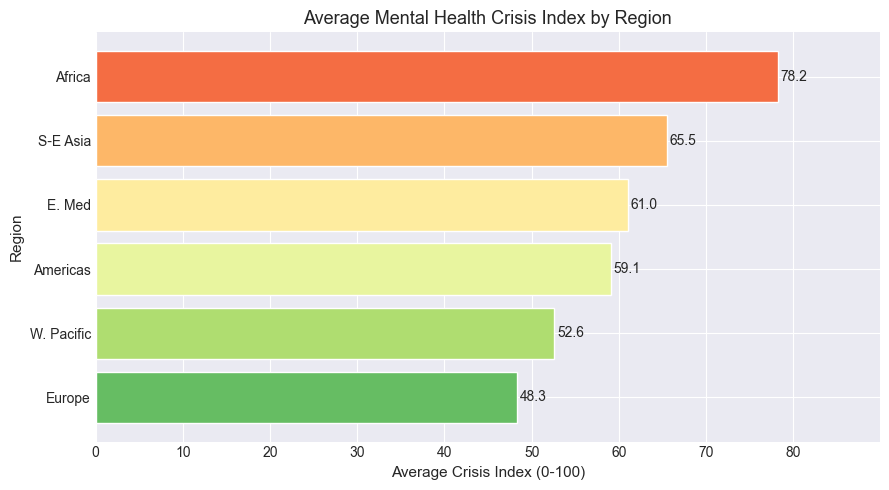

In [7]:
region_avg = df.groupby('region')['mh_crisis_index'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(region_avg)))
bars = ax.barh(region_avg.index, region_avg.values, color=colors, edgecolor='white')

for bar, val in zip(bars, region_avg.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10)

ax.set_title('Average Mental Health Crisis Index by Region', fontsize=13)
ax.set_xlabel('Average Crisis Index (0-100)', fontsize=11)
ax.set_ylabel('Region', fontsize=11)
ax.set_xlim(0, region_avg.max() * 1.15)
plt.tight_layout()
plt.show()

### 1.2 Top 10 Worst & Best Countries

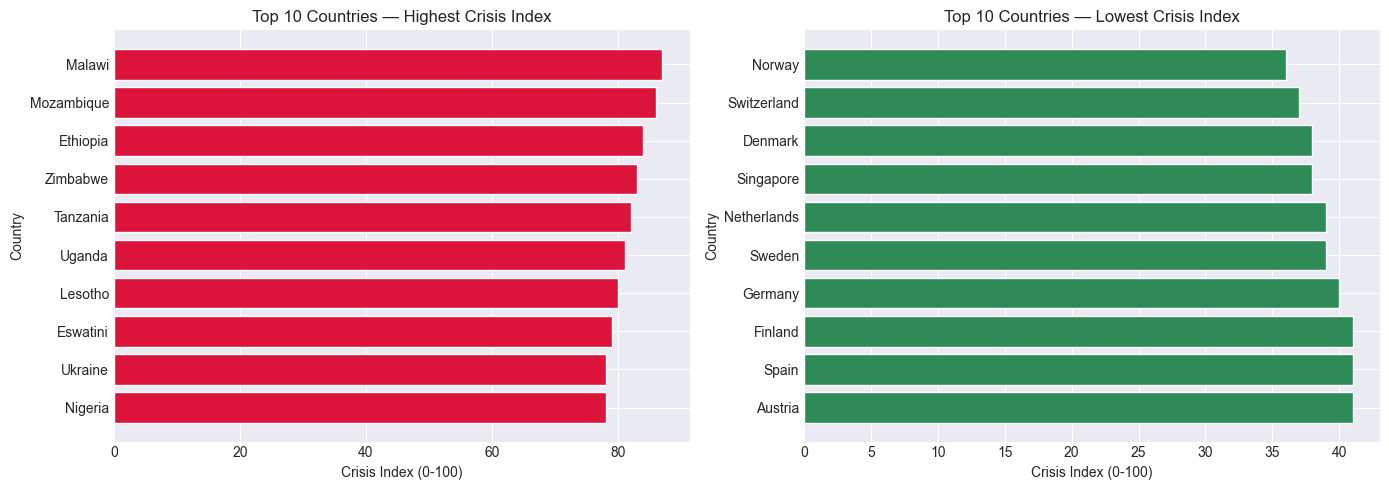

In [8]:
top10 = df.nlargest(10, 'mh_crisis_index')[['country', 'mh_crisis_index', 'region']]
bot10 = df.nsmallest(10, 'mh_crisis_index')[['country', 'mh_crisis_index', 'region']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10['country'], top10['mh_crisis_index'], color='crimson', edgecolor='white')
axes[0].set_title('Top 10 Countries — Highest Crisis Index', fontsize=12)
axes[0].set_xlabel('Crisis Index (0-100)', fontsize=10)
axes[0].set_ylabel('Country', fontsize=10)
axes[0].invert_yaxis()

axes[1].barh(bot10['country'], bot10['mh_crisis_index'], color='seagreen', edgecolor='white')
axes[1].set_title('Top 10 Countries — Lowest Crisis Index', fontsize=12)
axes[1].set_xlabel('Crisis Index (0-100)', fontsize=10)
axes[1].set_ylabel('Country', fontsize=10)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Use Case 1 — Conclusions

Africa has the most severe mental health crisis globally with an average crisis index of **78.2**, nearly 30 points higher than Europe (**48.3**). The top 10 worst countries are almost entirely African, while the top 10 best are almost entirely European. This regional divide reflects deep inequalities in healthcare resources, infrastructure, and investment. The worst country (Malawi ~85) scores more than double the best country (Norway ~36) — meaning where you are born has an enormous impact on your mental health outcomes.

---
## Use Case 2 — Social Media & Mental Health
### Is screen time making the crisis worse?

We explore whether countries where people spend more hours on social media show higher depression and anxiety rates. This is a **CDA** — comparing two numerical variables using scatter plots and then verifying the relationship with statistical tests.

### 2.1 Social Media Hours vs Depression Rate

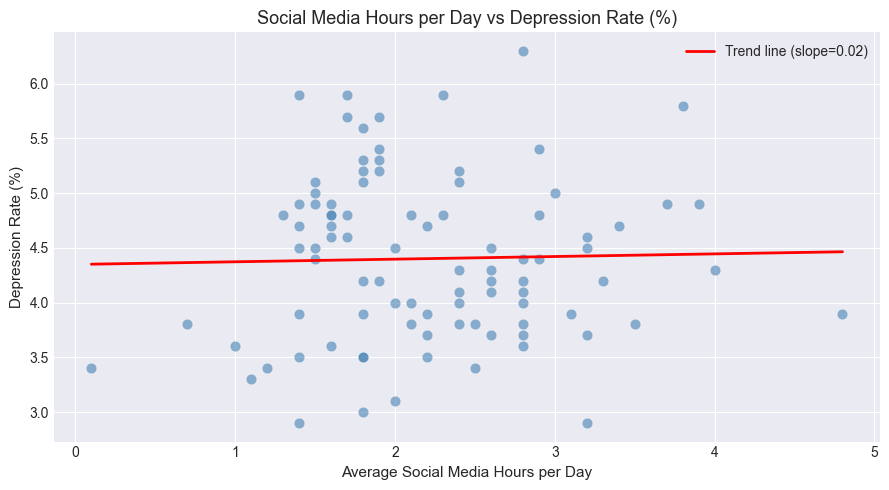

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['social_media_hours_daily'], df['depression_pct'],
           alpha=0.6, color='steelblue', s=60, edgecolors='white', linewidth=0.5)

m, b = np.polyfit(df['social_media_hours_daily'], df['depression_pct'], 1)
x_line = np.linspace(df['social_media_hours_daily'].min(),
                     df['social_media_hours_daily'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'Trend line (slope={m:.2f})')

ax.set_title('Social Media Hours per Day vs Depression Rate (%)', fontsize=13)
ax.set_xlabel('Average Social Media Hours per Day', fontsize=11)
ax.set_ylabel('Depression Rate (%)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Social Media Hours vs Anxiety Rate

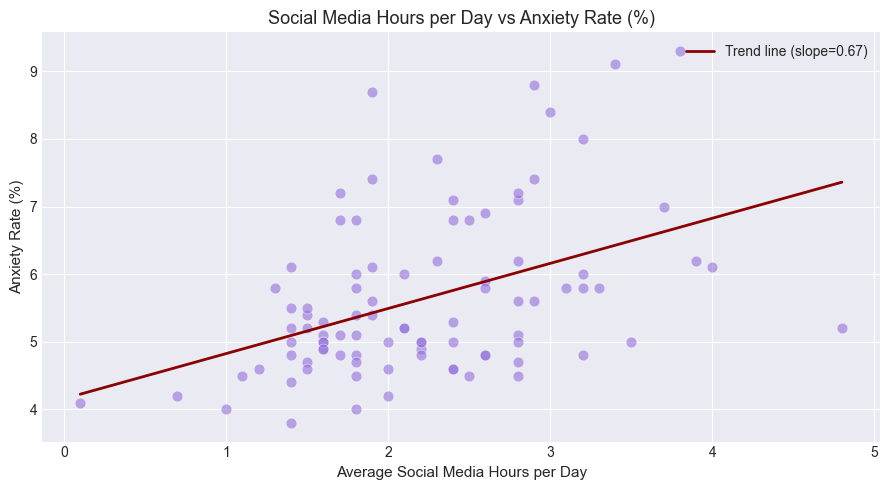

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['social_media_hours_daily'], df['anxiety_pct'],
           alpha=0.6, color='mediumpurple', s=60, edgecolors='white', linewidth=0.5)

m, b = np.polyfit(df['social_media_hours_daily'], df['anxiety_pct'], 1)
x_line = np.linspace(df['social_media_hours_daily'].min(),
                     df['social_media_hours_daily'].max(), 100)
ax.plot(x_line, m * x_line + b, color='darkred', linewidth=2,
        label=f'Trend line (slope={m:.2f})')

ax.set_title('Social Media Hours per Day vs Anxiety Rate (%)', fontsize=13)
ax.set_xlabel('Average Social Media Hours per Day', fontsize=11)
ax.set_ylabel('Anxiety Rate (%)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

### Use Case 2 — Conclusions

Social media appears to have a stronger relationship with anxiety than with depression. When we compared screen time against depression rates, the trend line was almost flat — showing a very weak relationship. But when we switched to anxiety rates, the trend line went clearly upward, with a much steeper slope. This tells us that as social media usage increases at the country level, anxiety rates tend to rise — while depression rates remain largely unaffected. The conclusion is that social media's mental health impact is more strongly linked to anxiety than to depression

---
## Use Case 3 — COVID-19 Aftermath
### Which regions suffered the most mental health impact from the pandemic?

The column `covid_mh_increase_pct` estimates the % increase in mental health burden post-COVID for each country. We analyze which regions were hit hardest and whether harder-hit countries ended up with worse crisis scores today. This is a **CDA** — comparing numerical COVID impact across categorical groups (regions) and against another numerical variable (crisis index).

### 3.1 Average COVID Mental Health Impact by Region

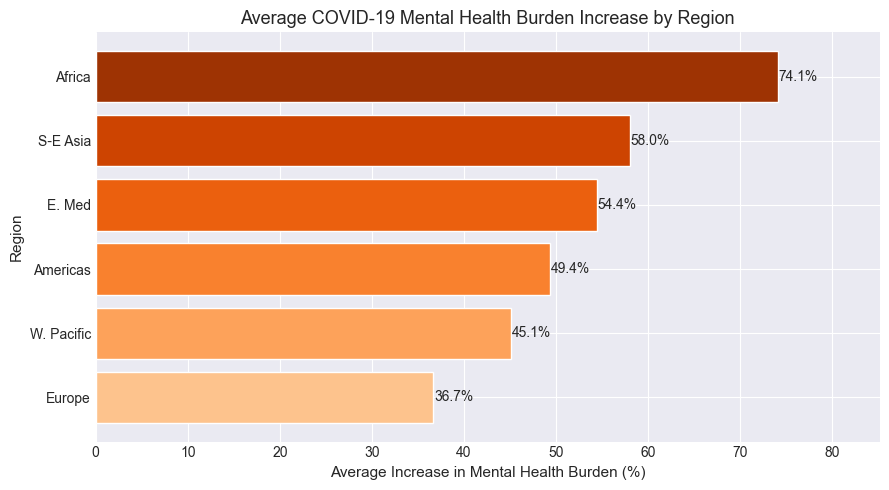

In [12]:
covid_region = df.groupby('region')['covid_mh_increase_pct'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.Oranges(np.linspace(0.3, 0.9, len(covid_region)))
bars = ax.barh(covid_region.index, covid_region.values, color=colors, edgecolor='white')

for bar, val in zip(bars, covid_region.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_title('Average COVID-19 Mental Health Burden Increase by Region', fontsize=13)
ax.set_xlabel('Average Increase in Mental Health Burden (%)', fontsize=11)
ax.set_ylabel('Region', fontsize=11)
ax.set_xlim(0, covid_region.max() * 1.15)
plt.tight_layout()
plt.show()

### 3.2 COVID Impact vs Current Crisis Index

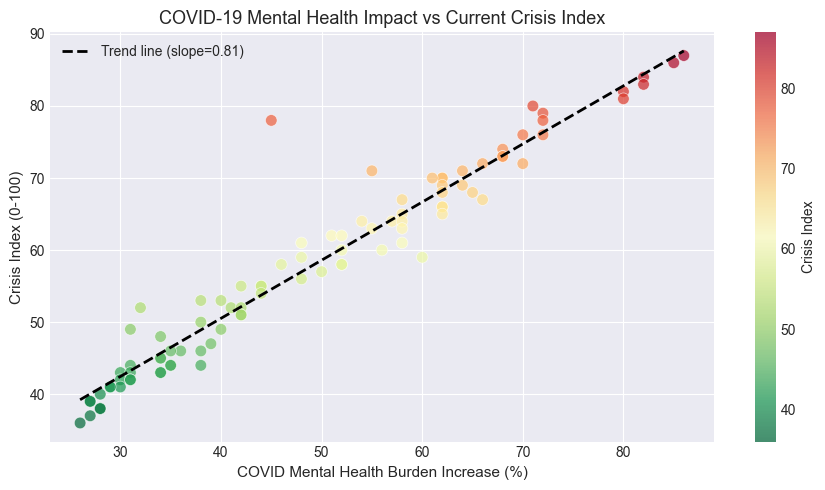

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(df['covid_mh_increase_pct'], df['mh_crisis_index'],
                     c=df['mh_crisis_index'], cmap='RdYlGn_r',
                     alpha=0.7, s=70, edgecolors='white', linewidth=0.5)

m, b = np.polyfit(df['covid_mh_increase_pct'], df['mh_crisis_index'], 1)
x_line = np.linspace(df['covid_mh_increase_pct'].min(),
                     df['covid_mh_increase_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2, linestyle='--',
        label=f'Trend line (slope={m:.2f})')

plt.colorbar(scatter, ax=ax, label='Crisis Index')
ax.set_title('COVID-19 Mental Health Impact vs Current Crisis Index', fontsize=13)
ax.set_xlabel('COVID Mental Health Burden Increase (%)', fontsize=11)
ax.set_ylabel('Crisis Index (0-100)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

### Use Case 3 — Conclusions

COVID-19 did not affect all regions equally. Africa experienced the largest mental health burden increase at **74.1%**, while Europe — with its stronger healthcare systems — only saw a **36.7%** increase. The colored scatter plot reveals a clear positive relationship: countries that were already in crisis (red dots) also suffered the highest COVID mental health impact. This confirms a double burden — the regions that needed the most support going into the pandemic were the least resilient when it hit.

---
## Use Case 4 — Policy Analysis
### Do mental health laws and budgets reduce the treatment gap?

We check whether having formal mental health policies and spending more on mental health translates into better care access. This is a **CDA** — we compare treatment gaps across policy groups and use an independent t-test to confirm statistical significance.

### 4.1 Treatment Gap: Countries With vs Without Mental Health Policy

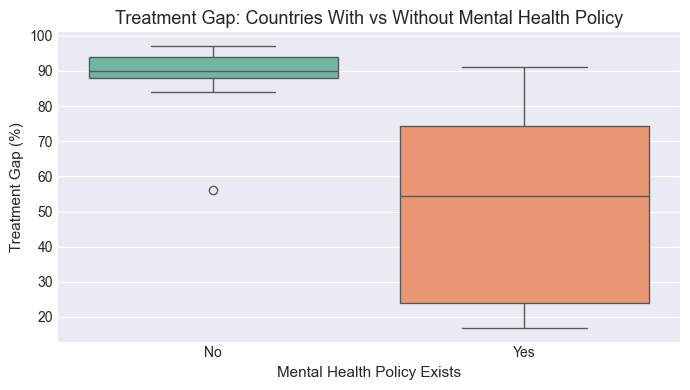

                  mean  median
mh_policy_exists              
No               89.30   90.00
Yes              50.50   54.50


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='mh_policy_exists', y='treatment_gap_pct',
            palette='Set2', ax=ax)
ax.set_title('Treatment Gap: Countries With vs Without Mental Health Policy', fontsize=13)
ax.set_xlabel('Mental Health Policy Exists', fontsize=11)
ax.set_ylabel('Treatment Gap (%)', fontsize=11)
plt.tight_layout()
plt.show()

print(df.groupby('mh_policy_exists')['treatment_gap_pct'].agg(['mean', 'median']))

### 4.2 Statistical Test — Independent t-Test (Policy vs No Policy)

In [16]:
groups = df['mh_policy_exists'].unique()
g1 = df[df['mh_policy_exists'] == groups[0]]['treatment_gap_pct']
g2 = df[df['mh_policy_exists'] == groups[1]]['treatment_gap_pct']

t, p = stats.ttest_ind(g1, g2)

print("Independent t-Test: Treatment Gap — Policy vs No Policy")
print(f"  t-statistic = {t:.4f}")
print(f"  p-value     = {p:.6f}")
print(f"  => {'Significant difference' if p < 0.05 else 'No significant difference'} at alpha=0.05")
print()
for g in groups:
    mean = df[df['mh_policy_exists'] == g]['treatment_gap_pct'].mean()
    print(f'Mean treatment gap ({g}): {mean:.1f}%')

Independent t-Test: Treatment Gap — Policy vs No Policy
  t-statistic = 6.7034
  p-value     = 0.000000
  => Significant difference at alpha=0.05

Mean treatment gap (No): 89.3%
Mean treatment gap (Yes): 50.5%


### 4.3 Mental Health Budget vs Treatment Gap

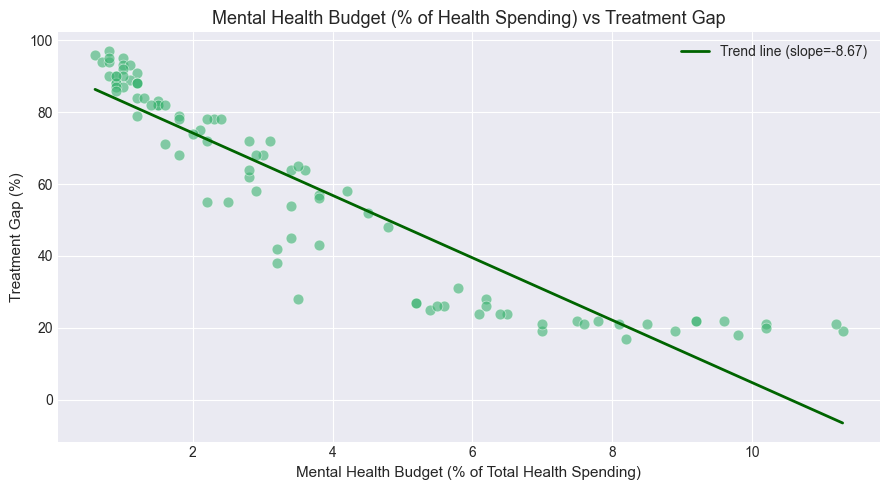

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['mh_budget_pct_health'], df['treatment_gap_pct'],
           alpha=0.6, color='mediumseagreen', s=60, edgecolors='white', linewidth=0.5)

m, b = np.polyfit(df['mh_budget_pct_health'], df['treatment_gap_pct'], 1)
x_line = np.linspace(df['mh_budget_pct_health'].min(),
                     df['mh_budget_pct_health'].max(), 100)
ax.plot(x_line, m * x_line + b, color='darkgreen', linewidth=2,
        label=f'Trend line (slope={m:.2f})')

ax.set_title('Mental Health Budget (% of Health Spending) vs Treatment Gap', fontsize=13)
ax.set_xlabel('Mental Health Budget (% of Total Health Spending)', fontsize=11)
ax.set_ylabel('Treatment Gap (%)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

### Use Case 4 — Conclusions

Having a mental health policy makes a measurable difference — countries with a policy have an average treatment gap of **50.5%** compared to **89.3%** for countries without one. The independent t-test confirms this difference is statistically real (p = 0.000000), not random chance. However, policy alone is not enough — the budget scatter plot shows the strongest finding: every 1% increase in mental health budget reduces the treatment gap by **8.67 percentage points**. Countries with a policy but low funding still have high gaps. The conclusion is clear: **policy + funding together** is what actually closes the treatment gap.

---
## Use Case 5 — Inequality Research
### Does wealth determine your mental health fate?

We compare income groups across three key metrics: psychiatrists available, money spent per person, and treatment gaps. This is a **CDA** — comparing numerical variables across 4 income group categories and using ANOVA to confirm statistical significance.

### 5.1 Mental Health Resources & Gaps by Income Group

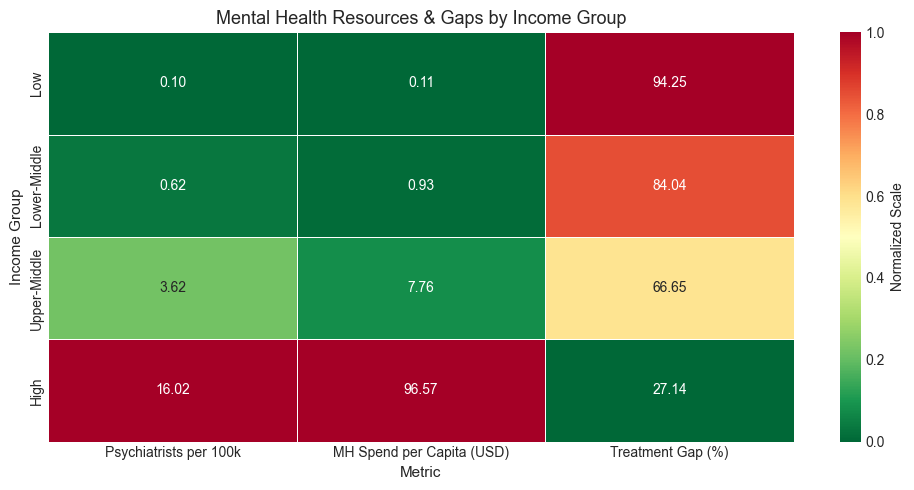

In [17]:
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']

heatmap_data = df.groupby('income_group')[['psychiatrists_per100k', 'mh_spend_usd_per_capita', 'treatment_gap_pct']].mean()
heatmap_data = heatmap_data.reindex(income_order)
heatmap_data.columns = ['Psychiatrists per 100k', 'MH Spend per Capita (USD)', 'Treatment Gap (%)']

heatmap_normalized = heatmap_data.copy()
for col in heatmap_normalized.columns:
    heatmap_normalized[col] = (heatmap_data[col] - heatmap_data[col].min()) / (heatmap_data[col].max() - heatmap_data[col].min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_normalized, annot=heatmap_data, fmt='.2f',
            cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Scale'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Mental Health Resources & Gaps by Income Group', fontsize=13)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Income Group', fontsize=11)
plt.tight_layout()
plt.show()

### 5.2 Statistical Test — One-Way ANOVA (Crisis Index across Income Groups)

In [18]:
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
groups = [df[df['income_group'] == g]['mh_crisis_index'] for g in income_order]
f, p = stats.f_oneway(*groups)

print("One-Way ANOVA: Crisis Index across Income Groups")
print(f"  F-statistic = {f:.4f}")
print(f"  p-value     = {p:.6f}")
print(f"  => {'Significant difference' if p < 0.05 else 'No significant difference'} at alpha=0.05")
print()
print('Mean crisis index by income group:')
print(df.groupby('income_group')['mh_crisis_index'].mean().reindex(income_order))

One-Way ANOVA: Crisis Index across Income Groups
  F-statistic = 141.5672
  p-value     = 0.000000
  => Significant difference at alpha=0.05

Mean crisis index by income group:
income_group
Low            81.38
Lower-Middle   68.81
Upper-Middle   59.65
High           44.31
Name: mh_crisis_index, dtype: float64


### Use Case 5 — Conclusions

Wealth is the strongest determinant of mental health outcomes in this dataset. High income countries have **160x more psychiatrists** per person and spend **966x more** on mental health than low income countries — resulting in a treatment gap of only **27.1%** compared to **94.2%** for low income countries. The One-Way ANOVA confirms these differences across all 4 income groups are statistically significant (F = 141.57, p = 0.000000) — one of the strongest statistical results in the entire analysis. Every step up the income ladder brings a consistent 12–15 point improvement in crisis index, from 81.4 (Low) down to 44.3 (High).

---
## Key Findings

1. **Africa has the most severe mental health crisis globally** — with an average crisis index of 78.2, nearly 30 points higher than Europe (48.3). The worst country (Malawi ~85) scores more than double the best country (Norway ~36).

2. **Social media has a stronger relationship with anxiety than depression** — countries in the Very High screen time category show noticeably higher anxiety rates, while depression rates remain relatively flat across all social media risk categories.

3. **COVID-19 hit already-struggling regions the hardest** — Africa saw a 74.1% increase in mental health burden post-pandemic compared to only 36.7% in Europe. The regions with the weakest healthcare systems had the least resilience to absorb the shock.

4. **Mental health policy cuts the treatment gap nearly in half, but funding is what makes it work** — countries with a policy average a 50.5% treatment gap vs 89.3% without one (t-test p = 0.000000). Every 1% increase in mental health budget reduces the treatment gap by 8.67 percentage points.

5. **Wealth is the strongest determinant of mental health outcomes** — high income countries have 160x more psychiatrists, spend 966x more per person, and have a treatment gap of 27% vs 94% in low income countries. ANOVA confirms this is one of the strongest relationships in the dataset (F = 141.57, p = 0.000000).

## Overall Conclusion

The global mental health crisis is deeply unequal — shaped by wealth, policy decisions, digital environments, and the lasting shadow of COVID-19. Where you are born largely determines your mental health fate. Africa vs Europe, rich vs poor, high social media exposure vs low — the gaps are enormous and statistically proven. Addressing this crisis requires targeted investment in low-income countries, properly funded mental health legislation, and awareness of the role digital habits play in population-level mental health.

## Future Work

- **Expand social media analysis:** Separate passive vs active social media use to better understand which behaviors specifically drive anxiety increases.
- **Policy quality index:** Go beyond Yes/No policy existence to measure the quality and funding level of mental health policies across countries.
- **Post-COVID longitudinal study:** Track whether the COVID-era mental health surge is recovering or becoming permanent across different regions.
